/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


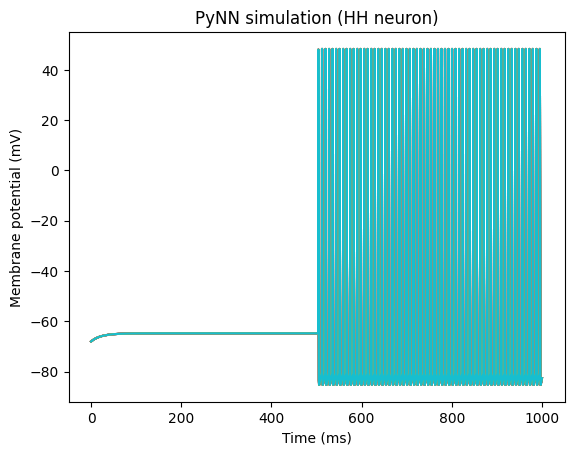

In [1]:
##### Add in the STN neurons and just use a DC current source ####
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector

v_init = -68
rng_seed = 856

############ Setup the simulation##########
sim.setup(timestep=0.01)

###########Set up the structure############
STN_space = space.RandomStructure(boundary=space.Sphere(2000), rng=NumpyRNG(seed=rng_seed))

###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(100, cortical_type, structure=STN_space, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(100, STN_type, structure=STN_space, initial_values={'v': v_init}, label="STN neurons")


############ set up the current ##############
start = 500
stop = 1000
cortical_pop.inject(sim.DCSource(start=start, stop=stop, amplitude=1))


########### check the position of the cortical neurons ##############
for Cortical_cell in cortical_pop:
    while (
        (np.abs(Cortical_cell.position[0]) > 2000)
        or ((np.abs(Cortical_cell.position[1]) > 2000))
    ) or (
        (np.abs(Cortical_cell.position[0]) < 500)
        and (-1500 < Cortical_cell.position[1] < 2000)
    ):
        Cortical_cell.position = STN_space.generate_positions(1).flatten()

for STN_cell in STN_pop:
    while (
        (np.abs(STN_cell.position[0]) > 2000)
        or ((np.abs(STN_cell.position[1]) > 2000))
    ) or (
        (np.abs(STN_cell.position[0]) < 500)
        and (-1500 < STN_cell.position[1] < 2000)
    ):
        STN_cell.position = STN_space.generate_positions(1).flatten()
    STN_cell.position[2] = 500

############# make the connections ############
syn_CorticalCollateralSTN = StaticSynapse(weight=0.12, delay=1)

prj_CorticalSTN = Projection(
    cortical_pop,
    STN_pop,
    FixedNumberPreConnector(n=5, allow_self_connections=False),
    syn_CorticalCollateralSTN,
    source="collateral(0.5)",
    receptor_type="excitatory",
)

######## Record membrane potential #############
#cortical_pop.record('v')

STN_pop.sample(10).record('v')

######### Run the simulation ###########
sim.run(1000)

############ Get and plot data ############
data = STN_pop.get_data().segments[0]
vm = data.filter(name="v")[0]

plt.plot(vm.times, vm)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("PyNN simulation (HH neuron)")
plt.show()

####### Clean up ###########
sim.end()

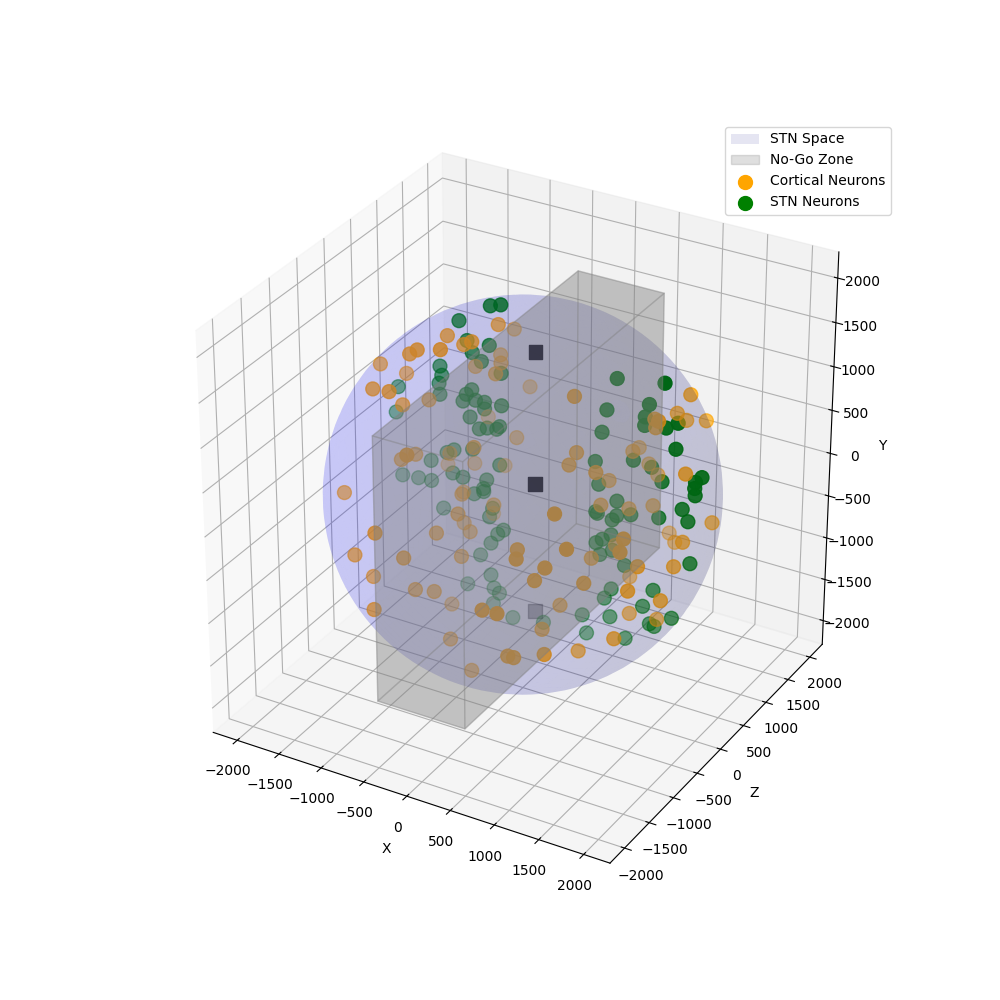

In [2]:
###### plot where the cortical neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget


#plot sphere of STN
theta = np.linspace(0, 2 * np.pi, 100)
phi = np.linspace(0, np.pi, 50)
theta, phi = np.meshgrid(theta, phi)
r = 2000

# Convert to Cartesian coordinates
x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, z, y, color = "blue",alpha=0.1, label = "STN Space")
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y')
ax.set_box_aspect((1, 1, 1))

#plot the stimulating electrode remeber y <-> z
ax.scatter(0, 250, 0, c='black', s=100, marker = "s")
#plot the receiving electrode
ax.scatter([0,0], [250,250], [-1500,1500], c='black', s=100, marker = "s")


#plot the no-go space
cube_vertices = np.array([
    [-500, -2000, -1500],  # point 0
    [ 500, -2000, -1500],  # point 1
    [ 500,  2000, -1500],  # point 2
    [-500,  2000, -1500],  # point 3
    [-500, -2000,  1500],  # point 4
    [ 500, -2000,  1500],  # point 5
    [ 500,  2000,  1500],  # point 6
    [-500,  2000,  1500],  # point 7
])

# Define cube faces using the vertices
faces = [
    [cube_vertices[i] for i in [0, 1, 2, 3]],  # bottom
    [cube_vertices[i] for i in [4, 5, 6, 7]],  # top
    [cube_vertices[i] for i in [0, 1, 5, 4]],  # front
    [cube_vertices[i] for i in [2, 3, 7, 6]],  # back
    [cube_vertices[i] for i in [1, 2, 6, 5]],  # right
    [cube_vertices[i] for i in [0, 3, 7, 4]]   # left
]
ax.add_collection3d(Poly3DCollection(faces, facecolors='gray', alpha=0.25, linewidths=1, edgecolor = 'gray', label = "No-Go Zone"))

##### add in the cortical neurons

x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]

ax.scatter(x_points_clean_ctx, z_points_clean_ctx, y_points_clean_ctx, c='orange', s=100, label = "Cortical Neurons")


##### add in the STN neurons##########
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]

ax.scatter(x_points_clean_stn, z_points_clean_stn, y_points_clean_stn, c='green', s=100, label = "STN Neurons")
ax.legend()

plt.show()

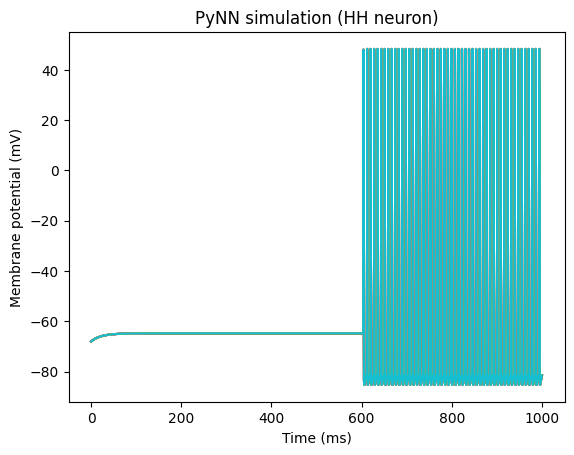

In [3]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector

v_init = -68
rng_seed = 856

############ Setup the simulation##########
sim.setup(timestep=0.01)

###########Set up the structure ############
cortical_space = space.RandomStructure(boundary=space.Cuboid(8000, 8000, 8000))
STN_space = space.RandomStructure(boundary=space.Cuboid(4000,4000,12000))

###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(100, cortical_type, structure=cortical_space, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(100, STN_type, structure=STN_space, initial_values={'v': v_init}, label="STN neurons")

########  offset the STN neurons ############
for STN_cell in STN_pop:
    STN_cell.position[2] = STN_cell.position[2] + 6000

##### check no neurons in the no go area####
# stn neurons
for STN_cell in STN_pop:
    while (
        (np.abs(STN_cell.position[0]) > 4000)
        or ((np.abs(STN_cell.position[1]) > 4000))
        or (np.abs(STN_cell.position[2]) > 12000)
    ) or (
        (-150 < STN_cell.position[0] < 150)
            and (-317.5 < STN_cell.position[2] < 317.5)
        ):
            STN_cell.position = STN_space.generate_positions(1).flatten()

for Cortical_cell in cortical_pop:
    while (
        (np.abs(Cortical_cell.position[0]) > 8000)
        or ((np.abs(Cortical_cell.position[1]) > 8000))
         or ((np.abs(Cortical_cell.position[2]) > 8000))
        ) or (
            (-150 < Cortical_cell.position[0] < 150)
            and (-67.5 < Cortical_cell.position[2] < 567.5) #z limit -317.5 < z < 317.5 but offset by +250
        ):
        Cortical_cell.position = cortical_space.generate_positions(1).flatten()

############ set up the current ##############
start = 600
stop = 1000
cortical_pop.inject(sim.DCSource(start=start, stop=stop, amplitude=1))

############# make the connections ############
syn_CorticalCollateralSTN = StaticSynapse(weight=0.12, delay=1)

prj_CorticalSTN = Projection(
    cortical_pop,
    STN_pop,
    FixedNumberPreConnector(n=5, allow_self_connections=False),
    syn_CorticalCollateralSTN,
    source="collateral(0.5)",
    receptor_type="excitatory",
)

######## Record membrane potential from the STN neurons #############
#cortical_pop.record('v')

STN_pop.sample(10).record('v')

######### Run the simulation ###########
sim.run(1000)

############ Get and plot data ############
data = STN_pop.get_data().segments[0]
vm = data.filter(name="v")[0]

plt.plot(vm.times, vm)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("PyNN simulation (HH neuron)")
plt.show()

####### Clean up ###########
sim.end()

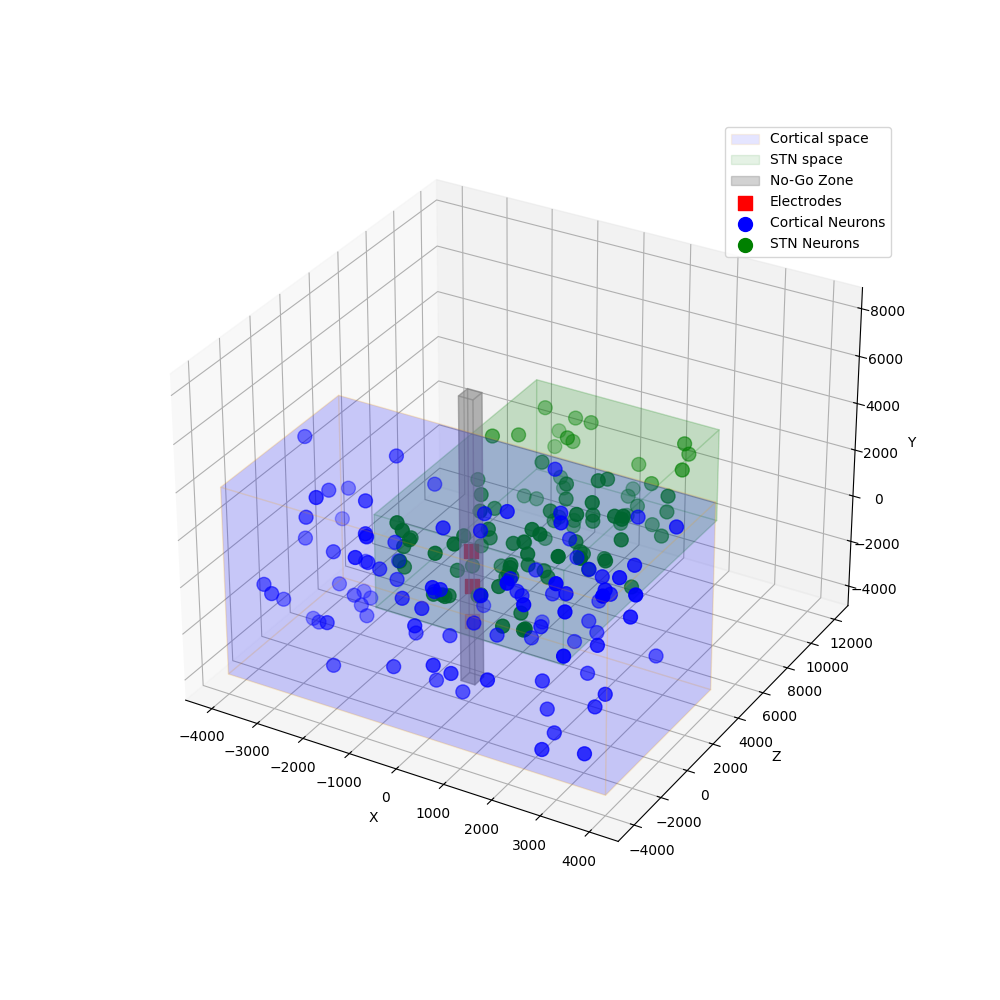

In [6]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y')

######## plot the cortical neuron space #############
#add the zone where there are no neurons
# Define cube vertices

# Define cube vertices
cube_vertices_ctx = np.array([
    [-4000, -4000, -4000],  # 0
    [4000, -4000, -4000],   # 1
    [4000, 4000, -4000],    # 2
    [-4000, 4000, -4000],   # 3
    [-4000, -4000, 4000],   # 4
    [4000, -4000, 4000],    # 5
    [4000, 4000, 4000],     # 6
    [-4000, 4000, 4000]     # 7
])

# Define cube faces using indices
faces = [
    [cube_vertices_ctx[i] for i in [0, 1, 2, 3]],  # bottom
    [cube_vertices_ctx[i] for i in [4, 5, 6, 7]],  # top
    [cube_vertices_ctx[i] for i in [0, 1, 5, 4]],  # front
    [cube_vertices_ctx[i] for i in [2, 3, 7, 6]],  # back
    [cube_vertices_ctx[i] for i in [1, 2, 6, 5]],  # right
    [cube_vertices_ctx[i] for i in [0, 3, 7, 4]]   # left
]

ax.add_collection3d(Poly3DCollection(faces, facecolors='blue', alpha=0.1, linewidths=1, edgecolor = 'orange', label = "Cortical space"))

######## plot the STN neuron space ################
#add the zone where there are no neurons
# Define cube vertices

# Define cube faces using the vertices
# Define cube vertices
cube_vertices_stn = np.array([
    [-2000, -6000+6000, -2000],  # point 0
    [2000, -6000+6000, -2000],  # point 1
    [2000, 6000+6000, -2000],  # point 2
    [-2000, 6000+6000, -2000],  # point 3
    [-2000, -6000+6000, 2000],  # point 0
    [2000, -6000+6000, 2000],  # point 1
    [2000, 6000+6000, 2000],  # point 2
    [-2000, 6000+6000, 2000],  # po
])

# Define cube faces using the vertices
faces = [
    [cube_vertices_stn[i] for i in [0, 1, 2, 3]],  # bottom
    [cube_vertices_stn[i] for i in [4, 5, 6, 7]],  # top
    [cube_vertices_stn[i] for i in [0, 1, 5, 4]],  # front
    [cube_vertices_stn[i] for i in [2, 3, 7, 6]],  # back
    [cube_vertices_stn[i] for i in [1, 2, 6, 5]],  # right
    [cube_vertices_stn[i] for i in [0, 3, 7, 4]]   # left
]

ax.add_collection3d(Poly3DCollection(faces, facecolors='green', alpha=0.1, linewidths=1, edgecolor = 'green', label = "STN space"))

########### add in the no-go space - remember physically y <-> z ############################
# x limin -150 < x < 150
#y limiit -4000< y < 4000
# z limit -317.5 < z < 317.5

#offset the cube vertices z coordinate by 250 because thats where the electrode is

#for show I have the electrode coming out the top of the STN space

cube_vertices = np.array([
    [-150.0, -317.5+250, -4000],  # point 0
    [ 150.0, -317.5+250, -4000],  # point 1
    [ 150.0,  317.5+250, -4000],  # point 2
    [-150.0,  317.5+250, -4000],  # point 3
    [-150.0, -317.5+250,  8000],  # point 4
    [ 150.0, -317.5+250,  8000],  # point 5
    [ 150.0,  317.5+250,  8000],  # point 6
    [-150.0,  317.5+250,  8000],  # point 7
])

# Define cube faces using the vertices
faces = [
    [cube_vertices[i] for i in [0, 1, 2, 3]],  # bottom
    [cube_vertices[i] for i in [4, 5, 6, 7]],  # top
    [cube_vertices[i] for i in [0, 1, 5, 4]],  # front
    [cube_vertices[i] for i in [2, 3, 7, 6]],  # back
    [cube_vertices[i] for i in [1, 2, 6, 5]],  # right
    [cube_vertices[i] for i in [0, 3, 7, 4]]   # left
]

ax.add_collection3d(Poly3DCollection(faces, facecolors='gray', alpha=0.35, linewidths=1, edgecolor = 'gray', label = "No-Go Zone"))

##########plot the stimulating electrode - remember y <-> z###########
ax.scatter(0, 250, 0, c='red', s=100, marker = "s")
#plot the receiving electrode
ax.scatter([0,0], [250,250], [-1500,1500], c='red', s=100, marker = "s", label = "Electrodes")

##### add in the cortical neurons##############
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]

ax.scatter(x_points_clean_ctx, z_points_clean_ctx, y_points_clean_ctx, c='blue', s=100, label = "Cortical Neurons")

##### add in the STN neurons##########
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]

ax.scatter(x_points_clean_stn, z_points_clean_stn, y_points_clean_stn, c='green', s=100, label = "STN Neurons")
ax.legend()

plt.show()